# Đồ án 2 - Phần 2: Hồi quy tuyến tính đa biến với bộ dữ liệu Bike Sharing
### Nhóm 13

---

## 1. Tiền xử lý dữ liệu và EDA (Người 1)

### 1.1. Thống kê mô tả và trực quan hóa (EDA)
- Vẽ biểu đồ phân phối (Histogram) của các biến liên tục.
- Vẽ biểu đồ hộp (Boxplot) phát hiện ngoại lệ (outlier).
- Vẽ ma trận tương quan (Heatmap) giữa các biến.
- Phân tích phân phối của biến mục tiêu `cnt`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Đảm bảo import được các module trong thư mục
sys.path.append(os.path.abspath('.'))

# Đọc dữ liệu gốc có missing
df_raw = pd.read_csv('data/day.csv')
df_raw.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2.0,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2.0,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1.0,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1.0,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1.0,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### 1.2. Xử lý Missing Values
- Cơ chế khuyết dữ liệu: Missing Completely At Random (MCAR).
- Áp dụng và so sánh các phương pháp điền khuyết (Mean, Median, KNN/Regression Imputation).
- So sánh phân phối trước và sau khi điền khuyết.

In [ ]:
# Code xử lý khuyết dữ liệu của Người 1

### 1.3. Gọi DataPipeline hoàn chỉnh

In [3]:
from data_pipeline import load_data
X_train, X_test, y_train, y_test, feature_names = load_data()
print("Kích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm thử:", X_test.shape)
print("Đặc trưng:", feature_names)

Kích thước tập huấn luyện: (584, 12)
Kích thước tập kiểm thử: (147, 12)
Đặc trưng: ['intercept', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


## 2. Mô tả dữ liệu & Mô hình OLS (Người 2)

### 2.1. Mô tả bộ dữ liệu
- Trình bày nguồn gốc bộ dữ liệu.
- Trình bày ý nghĩa của các biến trong bộ dữ liệu.
- Lý giải sự phù hợp của bộ dữ liệu đối với bài toán hồi quy.

### 2.2. Huấn luyện mô hình OLS Baseline
- Chạy hồi quy tuyến tính trên tất cả các đặc trưng ban đầu.

In [10]:
from model_comparison import run_ols_baseline, compute_metrics
beta_baseline, mae_base, rmse_base, r2_base = run_ols_baseline(X_train, X_test, y_train, y_test, feature_names)


🚀 MÔ HÌNH OLS BASELINE (ĐẦY ĐỦ ĐẶC TRƯNG)
Hiệu năng trên tập Test -> MAE: 654.4847 | RMSE: 860.6005 | R²: 0.8108

Đặc trưng       | Hệ số Beta   | Sai số chuẩn | t-stat     | Khoảng tin cậy 95%  
--------------------------------------------------------------------------------
Intercept       | 4496.5993    | 36.7845      | 122.2416   | [4424.350, 4568.849]
season          | 565.1057     | 66.8002      | 8.4596     | [433.902, 696.309]  
yr              | 1016.2398    | 37.1423      | 27.3607    | [943.288, 1089.192] 
mnth            | -143.9362    | 64.7640      | -2.2225    | [-271.141, -16.732] 
holiday         | -84.9017     | 38.2438      | -2.2200    | [-160.017, -9.786]  
weekday         | 163.2503     | 37.1992      | 4.3885     | [90.187, 236.314]   
workingday      | 56.8537      | 38.4743      | 1.4777     | [-18.714, 132.422]  
weathersit      | -307.4729    | 46.0940      | -6.6706    | [-398.007, -216.939]
temp            | 941.9856     | 135.2341     | 6.9656     | [676.

### 2.3. Lựa chọn biến (OLS Selection)
- Phân tích đa cộng tuyến (VIF) và giá trị p-value.
- Loại bỏ các biến không có ý nghĩa thống kê hoặc đa cộng tuyến cao.
- So sánh hiệu năng mô hình sau khi chọn biến.

In [11]:
from part2.model_comparison import run_ols_selection
# run_ols_selection(X_train, X_test, y_train, y_test, feature_names)

### 2.4. Phân tích phần dư (Residual Analysis)
- Vẽ 4 biểu đồ chẩn đoán phần dư trên mô hình OLS tốt nhất.
- Đưa ra nhận xét chi tiết về các giả định của mô hình.


[INFO] Đang kết xuất 4 biểu đồ chẩn đoán phần dư (Residual Analysis)...


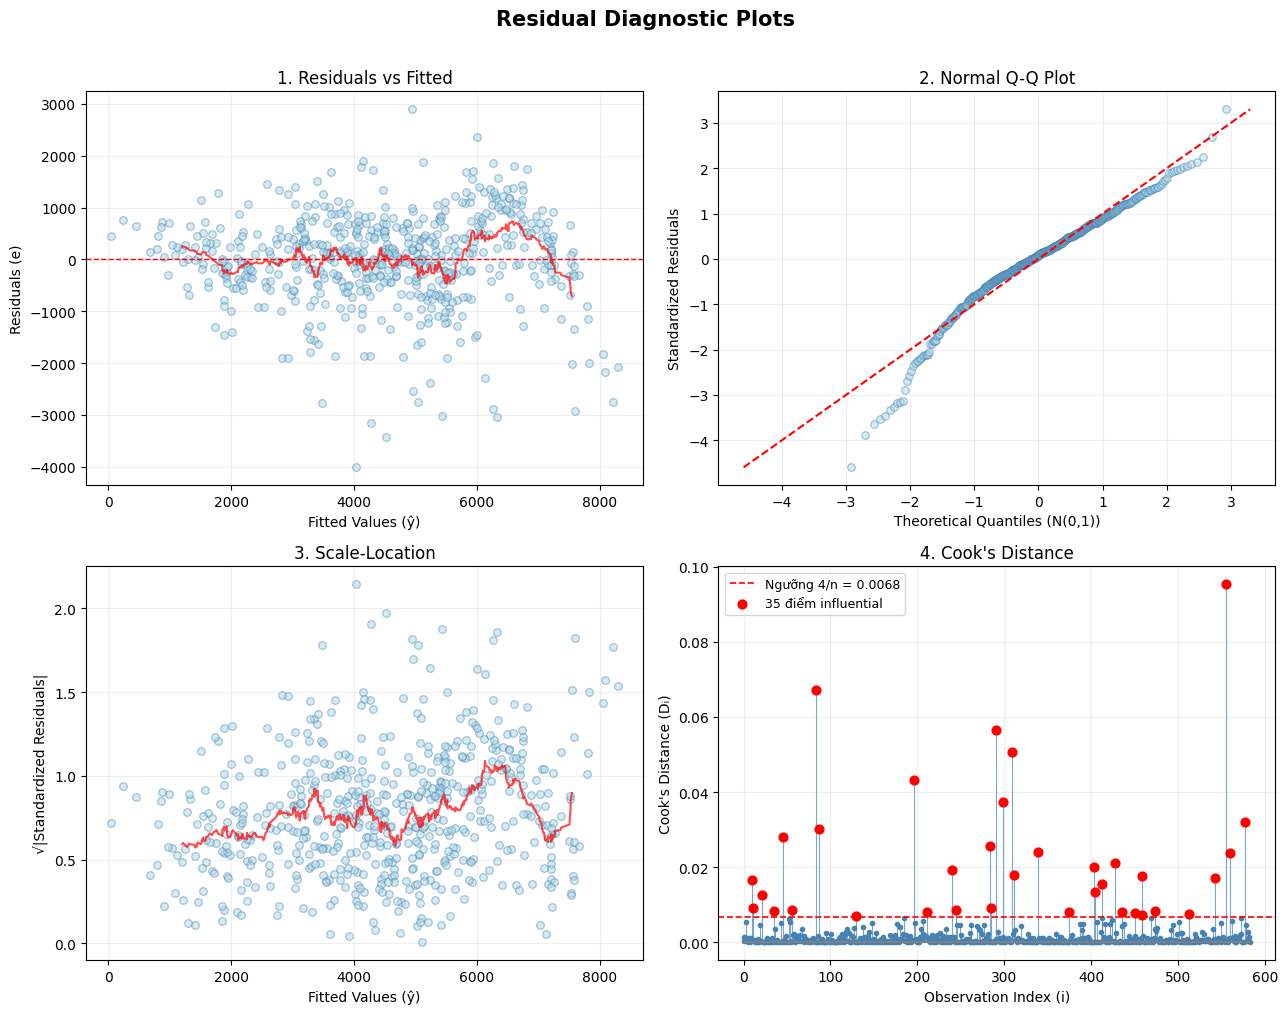


TÓM TẮT PHÂN TÍCH PHẦN DƯ
  Số quan sát: 584
  Số đặc trưng: 11
  RSS = 452000499.3337
  MSE = 790210.6632
  Ngưỡng Cook's Distance (4/n) = 0.0068
  Số điểm influential (Dᵢ > 4/n): 35
  Top influential points: [555, 83, 291, 309, 196]


In [12]:
from part2.model_comparison import plot_residuals
plot_residuals(X_train, y_train, beta_baseline)

## 3. Co rút hệ số - Ridge và Lasso (Người 3)

### 3.1. Hồi quy Ridge
- Sử dụng Cross-Validation để tìm tham số $\lambda$ tốt nhất.
- Vẽ đồ thị CV score (MSE) ứng với các giá trị $\lambda$ khác nhau.
- Trình bày kết quả đánh giá trên tập kiểm thử.


=== RIDGE REGRESSION ===

KẾT QUẢ CHỌN λ (RIDGE, 5-fold CV)
  λ tối ưu: 1.757511
  CV Score (MSE) tối ưu: 820935.1492
Lambda tốt nhất (Ridge): 1.757511


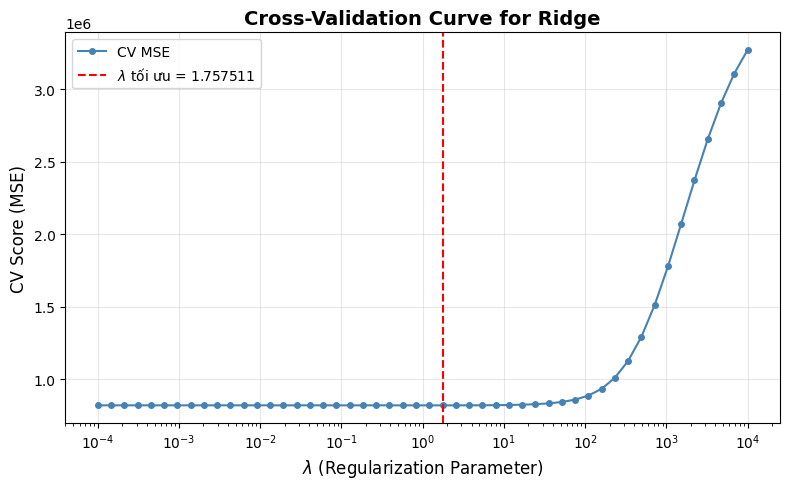

MAE:  654.5516
RMSE: 860.1927
R2:   0.8110


In [13]:
from part2.model_comparison import run_ridge
beta_ridge, best_lam_ridge, mae_r, rmse_r, r2_r = run_ridge(X_train, X_test, y_train, y_test, feature_names)

### 3.2. Hồi quy Lasso
- Sử dụng Cross-Validation để tìm tham số $\lambda$ tốt nhất.
- Nhận xét các đặc trưng có hệ số bị triệt tiêu về 0.
- Trình bày kết quả đánh giá trên tập kiểm thử.

In [ ]:
from part2.model_comparison import run_lasso
beta_lasso, best_lam_lasso, mae_l, rmse_l, r2_l = run_lasso(X_train, X_test, y_train, y_test, feature_names)

### 3.3. So sánh hiệu năng các mô hình và kết luận

In [ ]:
from part2.model_comparison import print_comparison_table
print_comparison_table(
    ols_res=(mae_base, rmse_base, r2_base),
    ols_select_res=None,  # Cập nhật từ Người 2
    ridge_res=(mae_r, rmse_r, r2_r),
    lasso_res=(mae_l, rmse_l, r2_l)
)

## 4. Phương pháp nâng cao (Người 4)

### 4.1. Kernel Ridge Regression (RBF Kernel)

In [ ]:
from part2.advanced_methods import kernel_ridge_predict
y_pred_kr = kernel_ridge_predict(X_train, y_train, X_test, lam=1.0, length_scale=1.0)
mae_kr, rmse_kr, r2_kr = compute_metrics(y_test, y_pred_kr)
print(f"Kernel Ridge Regression -> MAE: {mae_kr:.4f}, RMSE: {rmse_kr:.4f}, R2: {r2_kr:.4f}")

### 4.2. Bayesian Linear Regression
- Dự đoán khoảng tin cậy của biến mục tiêu.

In [ ]:
from part2.advanced_methods import bayesian_regression
y_pred_bay, m_n, S_n, y_var = bayesian_regression(X_train, y_train, X_test)
mae_bay, rmse_bay, r2_bay = compute_metrics(y_test, y_pred_bay)
print(f"Bayesian Linear Regression -> MAE: {mae_bay:.4f}, RMSE: {rmse_bay:.4f}, R2: {r2_bay:.4f}")